# Phase B — QLoRA Fine-Tuning
### MS Thesis: Generalizable Test Oracle for REST API Compliance

**Before running anything:**
1. `Runtime → Change runtime type → T4 GPU → Save`
2. Upload your `train.jsonl` and `val.jsonl` using the folder icon on the left
3. Run each cell top to bottom with `Shift+Enter`

---
**What this notebook does:**
- Loads `Llama-3-8B-Instruct` in 4-bit quantized format
- Attaches a QLoRA adapter (only ~42M parameters train)
- Fine-tunes for 3 epochs on your API oracle flashcards
- Saves the adapter and runs an inference test on an unseen API

In [1]:
# CELL 1 — Verify GPU
# Must show True before proceeding. If False, go to Runtime → Change runtime type → T4 GPU
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))
    print('VRAM:  ', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    raise RuntimeError('No GPU detected. Go to Runtime → Change runtime type → T4 GPU')

GPU available: True
Device: Tesla T4
VRAM:   15.6 GB


In [2]:
# CELL 2 — Install libraries (run once per Colab session)
#
# IMPORTANT: Colab pre-installs a specific PyTorch + CUDA build. A bare
# `pip install unsloth` can pull in a DIFFERENT, incompatible torch/xformers
# combination, which breaks an internal PyTorch API (the `_c10d_functional`
# namespace) that Unsloth's compiled kernels expect. This shows up as:
#   AttributeError: '_OpNamespace' '_c10d_functional' object has no attribute ...
# This is a known, common Colab/Unsloth environment issue, not a code bug.
#
# Fix: use --no-deps on the sensitive packages so pip does NOT cascade-upgrade
# torch underneath you, and force-reinstall unsloth cleanly (no stale cache).

!pip install -q --upgrade --force-reinstall --no-cache-dir --no-deps unsloth unsloth_zoo
!pip install -q --no-deps xformers trl peft accelerate bitsandbytes
!pip install -q jsonlines datasets transformers

print('Libraries installed.')
print()
print('=== ACTION REQUIRED ===')
print('Go to: Runtime -> Restart session  (NOT "Restart and run all", just Restart)')
print('Then re-run this notebook starting from Cell 1.')
print()
print('Why: if torch was upgraded/reinstalled while this Python process was already')
print('running, the process still holds the OLD torch bindings in memory. Re-running')
print('cells without a full restart will NOT pick up the fix and you will hit the')
print('same AttributeError again. A full restart is required after ANY cell that')
print('installs or upgrades torch-related packages.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 kB 157.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 MB 196.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.1 MB/s eta 0:00:00
Libraries installed.

=== ACTION REQUIRED ===
Go to: Runtime -> Restart session  (NOT "Restart and run all", just Restart)
Then re-run this notebook starting from Cell 1.

Why: if torch was upgraded/reinstalled while this Python process was already
running, the process still holds the OLD torch bindings in memory. Re-running
cells without a full restart will NOT pick up the fix and you will hit the
same AttributeError again. A full restart is required after ANY cell that
installs or upgrades torch-related packages.


In [3]:
# CELL 3 — Load base model
# Downloads Llama-3-8B-Instruct in 4-bit format (~4.5 GB, cached after first run)
#
# If you hit repeated 504 errors on huggingface.co here, this is a known, currently
# widespread Colab<->HuggingFace connectivity issue (see huggingface_hub #4085,
# googlecolab/colabtools #5947) -- not a code problem. These two lines are the two
# most-reported fixes: raising the HEAD-request timeout (default is only 10s, too
# short when HF's servers are slow rather than fully down) and using an HF_TOKEN
# (add one via the Colab key-icon secrets panel first) since authenticated requests
# get less aggressive rate-limiting even for public models.
import os
os.environ['HF_HUB_ETAG_TIMEOUT'] = '60'
try:
    from google.colab import userdata
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
    print('HF_TOKEN loaded from Colab secrets.')
except Exception:
    print('No HF_TOKEN secret found -- add one via the key icon in the left sidebar')
    print('if 504 errors persist (huggingface.co/settings/tokens).')

from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = 'unsloth/llama-3-8b-Instruct-bnb-4bit',
    max_seq_length = 2048,
    load_in_4bit   = True,
    dtype          = None,   # auto: bf16 on A100, fp16 on T4
)
print('Base model loaded successfully.')

No HF_TOKEN secret found -- add one via the key icon in the left sidebar
if 504 errors persist (huggingface.co/settings/tokens).
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.7.4: Fast Llama patching. Transformers: 5.13.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3-8b-Instruct-bnb-4bit as a legacy tokenizer.


Base model loaded successfully.


In [4]:
# CELL 4 — Attach QLoRA adapter
# r=8/alpha=16/dropout=0.1: reduced capacity + more regularization, confirmed
# best-performing setting from the no-spec experiments -- kept identical here
# so this run only varies ONE thing (spec shown or not), not multiple settings.
model = FastLanguageModel.get_peft_model(
    model,
    r                   = 8,     # LoRA rank
    lora_alpha          = 16,    # scaling
    lora_dropout        = 0.1,   # regularization
    target_modules      = ['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    bias                = 'none',
    use_gradient_checkpointing = True,
    random_state        = 42,
)
model.print_trainable_parameters()


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.7.4 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 6,815,744 || all params: 8,037,076,992 || trainable%: 0.0848


In [5]:
# CELL 5 — Load and format dataset
# Converts your JSONL flashcards into Llama-3 chat template format

import jsonlines
from datasets import Dataset

def format_record(r):
    """
    Converts a JSONL flashcard into the Llama-3 instruct chat format.
    The model learns to predict the assistant turn given system + user turns.
    """
    msgs = r['messages']
    return (
        '<|begin_of_text|>'
        '<|start_header_id|>system<|end_header_id|>\n'
        f"{msgs[0]['content']}<|eot_id|>"
        '<|start_header_id|>user<|end_header_id|>\n'
        f"{msgs[1]['content']}<|eot_id|>"
        '<|start_header_id|>assistant<|end_header_id|>\n'
        f"{msgs[2]['content']}<|eot_id|>"
    )

# Load train and val splits
# WITH-SPEC RUN: uses train_with_spec.jsonl / val_with_spec.jsonl -- make sure
# you uploaded THESE files (not the plain train.jsonl/val.jsonl) to this session.
with jsonlines.open('train_with_spec.jsonl') as f:
    train_texts = [format_record(r) for r in f]

with jsonlines.open('val_with_spec.jsonl') as f:
    val_texts = [format_record(r) for r in f]

train_ds = Dataset.from_dict({'text': train_texts})
val_ds   = Dataset.from_dict({'text': val_texts})

print(f'Train: {len(train_texts)} records')
print(f'Val:   {len(val_texts)} records')
print()
print('Sample formatted record (first 400 chars):')
print(train_texts[0][:400], '...')

Train: 1476 records
Val:   370 records

Sample formatted record (first 400 chars):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a REST API test oracle. Given an OpenAPI specification for the relevant field, an HTTP request, and an HTTP response, determine whether the response is correct. Return VERDICT (PASS or FAIL), BUG_TYPE, and REASONING.<|eot_id|><|start_header_id|>user<|end_header_id|>
API: JSONPlaceholder API 1.0
Spec (relevant field only): {"id": { ...


In [6]:
# CELL 6 — Configure and run training (WITH-SPEC RUN)
# Settings match the best confirmed no-spec run exactly (1 epoch, lr=5e-5,
# response-only loss masking) so this experiment isolates ONE variable: whether
# showing the model the relevant spec field changes its performance.

from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only

sft_config_kwargs = dict(
    output_dir                  = './api-oracle-model-with-spec',
    num_train_epochs            = 1,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    learning_rate               = 5e-5,
    warmup_steps                = 10,
    logging_steps                = 5,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    fp16  = not torch.cuda.is_bf16_supported(),
    bf16  = torch.cuda.is_bf16_supported(),
    report_to = 'none',
    seed = 42,
    dataset_text_field = 'text',
    max_seq_length = 2048,
    packing = False,
    padding_free = False,
)

def build_sft_config(kwargs):
    kwargs = dict(kwargs)
    while True:
        try:
            return SFTConfig(**kwargs)
        except TypeError as e:
            msg = str(e)
            marker = "unexpected keyword argument '"
            if marker in msg:
                bad_key = msg.split(marker, 1)[1].split("'", 1)[0]
                if bad_key in kwargs:
                    print(f'  [compat] Installed trl version rejects "{bad_key}" -- dropping it and retrying.')
                    kwargs.pop(bad_key)
                    continue
            raise

training_args = build_sft_config(sft_config_kwargs)

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    args          = training_args,
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n",
    response_part = "<|start_header_id|>assistant<|end_header_id|>\n",
)
print("Grading the model only on its own answer, not the input it was given.")

print('Starting training (WITH-SPEC run)...')
print('Watch the eval_loss column — it should decrease each epoch.')
print()

train_result = trainer.train()

print()
print('=== Training complete (WITH-SPEC) ===')
print(f'Total steps     : {train_result.global_step}')
print(f'Training loss   : {train_result.training_loss:.4f}')
print(f'Time taken      : {train_result.metrics["train_runtime"]:.0f}s')


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1476 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/370 [00:00<?, ? examples/s]

Map:   0%|          | 0/1476 [00:00<?, ? examples/s]

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

Grading the model only on its own answer, not the input it was given.
Starting training (WITH-SPEC run)...
Watch the eval_loss column — it should decrease each epoch.



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,476 | Num Epochs = 1 | Total steps = 185
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 6,815,744 of 8,037,076,992 (0.08% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.000182,2.331429


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


=== Training complete (WITH-SPEC) ===
Total steps     : 185
Training loss   : 0.2130
Time taken      : 2541s


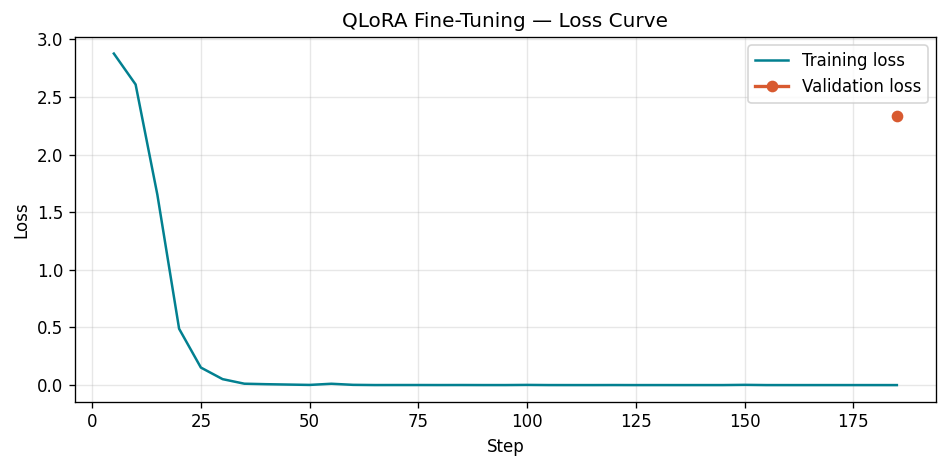

Loss curve saved as loss_curve.png
Best epoch: 1 (eval_loss = 2.3314)


In [7]:
# CELL 7 — Plot training loss curve
# Save this chart — it goes into your thesis Chapter 4

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

logs = trainer.state.log_history

train_steps  = [l['step'] for l in logs if 'loss' in l and 'eval_loss' not in l]
train_losses = [l['loss'] for l in logs if 'loss' in l and 'eval_loss' not in l]
eval_steps   = [l['step'] for l in logs if 'eval_loss' in l]
eval_losses  = [l['eval_loss'] for l in logs if 'eval_loss' in l]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_steps, train_losses, color='#028090', label='Training loss', linewidth=1.5)
ax.plot(eval_steps,  eval_losses,  color='#D85A30', label='Validation loss',
        linewidth=2, marker='o', markersize=6)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('QLoRA Fine-Tuning — Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', bbox_inches='tight')
plt.show()
print('Loss curve saved as loss_curve.png')

if eval_losses:
    best_epoch = eval_losses.index(min(eval_losses)) + 1
    print(f'Best epoch: {best_epoch} (eval_loss = {min(eval_losses):.4f})')

In [8]:
# CELL 8 — Save the LoRA adapter
# The adapter is ~80 MB — much smaller than the full 16 GB model

import os, shutil

ADAPTER_DIR = 'api-oracle-lora-adapter-with-spec'  # distinct name -- do not overwrite your existing adapter
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f'Adapter saved to {ADAPTER_DIR}/')
print('Files saved:')
for f in os.listdir(ADAPTER_DIR):
    size_mb = os.path.getsize(f'{ADAPTER_DIR}/{f}') / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

# Zip and download
shutil.make_archive(ADAPTER_DIR, 'zip', ADAPTER_DIR)
print(f'\nZipped as {ADAPTER_DIR}.zip')

try:
    from google.colab import files
    files.download(f'{ADAPTER_DIR}.zip')
    files.download('loss_curve.png')
    print('Download started.')
except ImportError:
    print('Not in Colab — files saved to current directory.')

Unsloth: Restored added_tokens_decoder metadata in api-oracle-lora-adapter-with-spec/tokenizer_config.json.


Adapter saved to api-oracle-lora-adapter-with-spec/
Files saved:
  README.md  (0.0 MB)
  adapter_model.safetensors  (27.3 MB)
  adapter_config.json  (0.0 MB)
  tokenizer_config.json  (0.1 MB)
  tokenizer.json  (17.2 MB)
  chat_template.jinja  (0.0 MB)

Zipped as api-oracle-lora-adapter-with-spec.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


In [9]:
# CELL 9 — Quick sanity check (ILLUSTRATIVE ONLY -- not your real evaluation)
#
# This is a fast eyeball check that the model learned the task's input/output
# FORMAT correctly right after training. It is NOT run against your real sealed
# test APIs (SpaceX, Frankfurter, Open Library) and its results should NOT be
# reported as generalization evidence in your thesis.
#
# For the actual RQ2/RQ4 generalization evaluation: build test.jsonl from your
# three sealed APIs using the exact same corrected export pipeline used for
# train.jsonl/val.jsonl (no spec content, "API: / Request: / Response:" format,
# HTTP status line included), then run phase_c_fixed.ipynb for the full
# three-way Model A (baseline) / Model B (fine-tuned) / Model C (Claude) comparison.
#
# IMPORTANT: matches the corrected training format exactly -- the model is
# given ONLY the API name, request, and response. No OpenAPI spec is included,
# since the entire thesis claim is spec-free judgment at inference time.

FastLanguageModel.for_inference(model)   # switch model to inference mode

SYSTEM = (
    'You are a REST API test oracle. Given an API name, an HTTP request, '
    'and an HTTP response, determine whether the response is correct. '
    'Return VERDICT (PASS or FAIL), BUG_TYPE, and REASONING.'
)

# Hand-written illustrative cases only -- built to sanity-check that the model
# fires on obvious instances of each violation type. NOT drawn from your sealed
# test APIs. Format matches train.jsonl/val.jsonl exactly (no spec content).
test_cases = [
    {
        'desc': 'illustrative constraint_violation (negative price)',
        'input': (
            'API: Illustrative Sanity Check\n'
            'Request:\n'
            'GET /products/42\n\n'
            'Response:\n'
            'HTTP 200\n'
            '{"id":42,"name":"Laptop","price":-99.0,"stock":5,"category":"electronics"}'
        ),
        'expected': 'FAIL / constraint_violation'
    },
    {
        'desc': 'illustrative enum_violation (status not a declared value)',
        'input': (
            'API: Illustrative Sanity Check\n'
            'Request:\n'
            'GET /appointments/7\n\n'
            'Response:\n'
            'HTTP 200\n'
            '{"id":7,"patientId":103,"doctorId":203,"date":"2026-07-01",'
            '"time":"14:00","status":"rescheduled","type":"routine"}'
        ),
        'expected': 'FAIL / enum_violation'
    },
    {
        'desc': 'illustrative correct response',
        'input': (
            'API: Illustrative Sanity Check\n'
            'Request:\n'
            'GET /vehicles/1HGBH41JXMN109186\n\n'
            'Response:\n'
            'HTTP 200\n'
            '{"vin":"1HGBH41JXMN109186","make":"Honda","model":"Civic",'
            '"year":2021,"mileage":35000,"status":"available","fuelType":"petrol"}'
        ),
        'expected': 'PASS / correct'
    },
    {
        'desc': 'illustrative missing_required_field',
        'input': (
            'API: Illustrative Sanity Check\n'
            'Request:\n'
            'GET /products/11\n\n'
            'Response:\n'
            'HTTP 200\n'
            '{"id":11,"price":9.99,"stock":500,"category":"food"}'
        ),
        'expected': 'FAIL / missing_required_field'
    },
    {
        'desc': 'illustrative wrong_status_code (200 on an error body)',
        'input': (
            'API: Illustrative Sanity Check\n'
            'Request:\n'
            'POST /appointments\n\n'
            'Response:\n'
            'HTTP 200\n'
            '{"error":"Resource not found"}'
        ),
        'expected': 'FAIL / wrong_status_code'
    },
]

correct = 0
for i, tc in enumerate(test_cases, 1):
    prompt = (
        f'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n'
        f"{SYSTEM}<|eot_id|>"
        f'<|start_header_id|>user<|end_header_id|>\n'
        f"{tc['input']}<|eot_id|>"
        f'<|start_header_id|>assistant<|end_header_id|>\n'
    )
    inputs  = tokenizer(prompt, return_tensors='pt').to('cuda')
    outputs = model.generate(**inputs, max_new_tokens=200, temperature=0.1,
                              do_sample=False, pad_token_id=tokenizer.eos_token_id)
    out     = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer  = out.split('assistant')[-1].strip()

    verdict    = 'PASS' if 'VERDICT: PASS' in answer else 'FAIL'
    exp_v      = tc['expected'].split('/')[0].strip()
    exp_bt     = tc['expected'].split('/')[1].strip()
    verdict_ok = verdict == exp_v
    bugtype_ok = exp_bt in answer
    if verdict_ok and bugtype_ok: correct += 1

    status = 'CORRECT' if (verdict_ok and bugtype_ok) else 'WRONG'
    print(f'--- Test {i}: {tc["desc"]} ---')
    print(f'Expected : {tc["expected"]}')
    print(f'Got      : {answer[:200]}')
    print(f'Result   : {status}')
    print()

print(f'=== SANITY CHECK RESULT: {correct}/{len(test_cases)} correct ===')
print('These are hand-written illustrative cases, NOT your sealed test APIs.')
print('Do not report this as generalization evidence -- use phase_c_fixed.ipynb')
print('with a real test.jsonl (spacex/frankfurter/openlibrary) for that.')


Both `max_new_tokens` (=200) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

--- Test 1: illustrative constraint_violation (negative price) ---
Expected : FAIL / constraint_violation
Got      : VERDICT: PASS
BUG_TYPE: None
REASONING: The response is a successful HTTP response (200) and the JSON payload contains the expected fields and values for a product with ID 42. The product's name is "L
Result   : WRONG



Both `max_new_tokens` (=200) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Test 2: illustrative enum_violation (status not a declared value) ---
Expected : FAIL / enum_violation
Got      : VERDICT: PASS
BUG_TYPE: None
REASONING: The response is a successful GET request for a specific appointment with ID 7. The response contains the expected fields and values, including the appointment I
Result   : WRONG



Both `max_new_tokens` (=200) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Test 3: illustrative correct response ---
Expected : PASS / correct
Got      : VERDICT: PASS
BUG_TYPE: None
REASONING: The response is a successful HTTP 200 response, and the JSON payload matches the expected format and content. The vehicle information, including VIN, make, mode
Result   : CORRECT



Both `max_new_tokens` (=200) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Test 4: illustrative missing_required_field ---
Expected : FAIL / missing_required_field
Got      : VERDICT: PASS
BUG_TYPE: None
REASONING: The response is a successful HTTP 200 response, and the JSON payload contains the expected fields: "id", "price", "stock", and "category". The values for these 
Result   : WRONG

--- Test 5: illustrative wrong_status_code (200 on an error body) ---
Expected : FAIL / wrong_status_code
Got      : VERDICT: FAIL
BUG_TYPE: Unexpected Response
REASONING: The API is expected to return a 404 Not Found response when the resource is not found, but it returned a 200 OK response instead.
Result   : WRONG

=== SANITY CHECK RESULT: 1/5 correct ===
These are hand-written illustrative cases, NOT your sealed test APIs.
Do not report this as generalization evidence -- use phase_c_fixed.ipynb
with a real test.jsonl (spacex/frankfurter/openlibrary) for that.


In [10]:
# CELL 10 — Baseline comparison (pre-training model)
# Reload the base model WITHOUT the LoRA adapter and run the same 5 tests.
# The difference between baseline and fine-tuned scores is your training contribution.
# Run this BEFORE training in the real thesis run, save the output, then compare.

print('To measure baseline performance (before fine-tuning):')
print('1. Start a fresh Colab session')
print('2. Run Cells 1-3 only (load base model, NO LoRA adapter)')
print('3. Copy Cell 9 inference code and run it')
print('4. Record baseline scores')
print('5. Then run the full fine-tuning and compare')
print()
print('This gives you your RQ2 answer:')
print('  Baseline score  (raw Llama-3-8B, no fine-tuning)')
print('  Fine-tuned score (after QLoRA training on your dataset)')
print('  Difference = training contribution')

To measure baseline performance (before fine-tuning):
1. Start a fresh Colab session
2. Run Cells 1-3 only (load base model, NO LoRA adapter)
3. Copy Cell 9 inference code and run it
4. Record baseline scores
5. Then run the full fine-tuning and compare

This gives you your RQ2 answer:
  Baseline score  (raw Llama-3-8B, no fine-tuning)
  Fine-tuned score (after QLoRA training on your dataset)
  Difference = training contribution


## What you now have

| File | What it is |
|---|---|
| `api-oracle-lora-adapter.zip` | Your trained LoRA adapter weights |
| `loss_curve.png` | Training + validation loss chart for your thesis |

## Next: Phase C — Evaluation

Phase C runs your full test.jsonl (unseen APIs) through:
1. Baseline Llama-3-8B (no fine-tuning)
2. Your fine-tuned model
3. GPT-4o (or Claude as reference)

And computes F1, precision, recall, cost, and latency for each — producing your thesis Table 2.

### Key numbers to record from this run
- Final training loss
- Final validation loss  
- Best epoch number
- Quick test score (Cell 9): X/5 correct
- Training time in minutes

These go directly into your thesis **Chapter 3 (Methodology)** and **Chapter 4 (Results)**.